In [127]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml

In [128]:
data = fetch_openml(data_id=1597, as_frame=True)

X = data.data
y = data.target.astype(int)

In [129]:
print(X.head())

         V1        V2        V3        V4        V5        V6        V7  \
0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9       V10  ...       V20       V21       V22       V23  \
0  0.098698  0.363787  0.090794  ...  0.251412 -0.018307  0.277838 -0.110474   
1  0.085102 -0.255425 -0.166974  ... -0.069083 -0.225775 -0.638672  0.101288   
2  0.247676 -1.514654  0.207643  ...  0.524980  0.247998  0.771679  0.909412   
3  0.377436 -1.387024 -0.054952  ... -0.208038 -0.108300  0.005274 -0.190321   
4 -0.270533  0.817739  0.753074  ...  0.408542 -0.009431  0.798278 -0.137458   

        V24       V25       V26       V27       V28  Amount  
0  0.0

In [130]:
print(y.head())

0    0
1    0
2    0
3    0
4    0
Name: Class, dtype: int64


In [131]:
print("Shape(rows, attributes):",X.shape)
print("Columns: ", list(X.columns))
print()
print(y.value_counts())

print()
print("Missing Values:", X.isnull().sum().sum())
print("Duplicates:", X.duplicated().sum())

Shape(rows, attributes): (284807, 29)
Columns:  ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']

Class
0    284315
1       492
Name: count, dtype: int64

Missing Values: 0
Duplicates: 9144


In [132]:
fraud_rate = y.mean()
allNotFraud = 1 - fraud_rate
print(f"Fraud Rate: {fraud_rate:.3%}")
print(f"Accuracy if model classified all as legitimate: {allNotFraud:.3%}")
print(f"Frauds detected: 0 of {y.sum()}")

logLoss = -(fraud_rate*np.log(fraud_rate) + (1-fraud_rate)*np.log(1-fraud_rate))
print(f"Log loss (average penalty) if it always predicts the fraud rate: {logLoss:.4f}")

Fraud Rate: 0.173%
Accuracy if model classified all as legitimate: 99.827%
Frauds detected: 0 of 492
Log loss (average penalty) if it always predicts the fraud rate: 0.0127


In [133]:
from sklearn.model_selection import train_test_split
X_train, X_rem, y_train, y_rem = train_test_split(X, y, test_size=0.4, stratify=y, random_state=2)

In [134]:
X_val, X_test, y_val, y_test = train_test_split(X_rem, y_rem, test_size=0.5, stratify=y_rem, random_state=2)

In [135]:
for name, X_sets, y_sets in [("Training", X_train, y_train), ("Validation", X_val, y_val), ("Testing", X_test, y_test)]:
  print(f"{name}: {X_sets.shape[0]} rows, {y_sets.sum()} frauds, ({y_sets.mean():.5%})")

Training: 170884 rows, 295 frauds, (0.17263%)
Validation: 56961 rows, 98 frauds, (0.17205%)
Testing: 56962 rows, 99 frauds, (0.17380%)


In [136]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_trainScaled = scaler.fit_transform(X_train)
X_valScaled = scaler.transform(X_val)
X_testScaled = scaler.transform(X_test)

print(X_trainScaled[:,0].mean(), X_trainScaled[:,0].std())
print(X_valScaled[:,0].mean(), X_valScaled[:,0].std())
print(X_trainScaled.shape, X_valScaled.shape, X_testScaled.shape)


1.3721536410713294e-18 0.9999999999999999
-0.0011893840816954169 0.9906599835554472
(170884, 29) (56961, 29) (56962, 29)


In [137]:
def sigmoid(z):
  z = np.clip(z, -500, 500)
  return 1/(1+np.exp(-z))

def probability_prediction(X, w, b):
  return sigmoid(X @ w + b)

def bceLoss(p, y, eps=1e-10):
  p = np.clip(p, eps, 1-eps)
  return -np.mean(y * np.log(p) + (1-y) * np.log(1-p))

def gradient(X, y, p):
  remainder = p - y
  gradientw = X.T @ remainder / len(y)
  gradientb = remainder.mean()
  return gradientw, gradientb

In [138]:
yTrain = y_train.values

w = np.zeros(X_trainScaled.shape[1])
b = 0

learningRate = 0.5
epochs = 3000
history = []

for epoch in range(epochs):
  p = probability_prediction(X_trainScaled, w, b)
  loss = bceLoss(p, yTrain)
  gradientw, gradientb = gradient(X_trainScaled, yTrain, p)
  w -= learningRate * gradientw
  b -= learningRate * gradientb
  history.append(loss)


  if epoch % 500 == 0:
    print(f"Epoch: {epoch}, Loss: {loss:.4f}, Bias: {b:.4f}")

print(f"\nFinal Training Loss: {history[-1]:.6f}")
print(f"Baseline Loss (If it ignores all features and just outputs the known fraud rate): {logLoss:.4f}")

Epoch: 0, Loss: 0.6931, Bias: -0.2491
Epoch: 500, Loss: 0.0076, Bias: -5.4382
Epoch: 1000, Loss: 0.0057, Bias: -6.0967
Epoch: 1500, Loss: 0.0051, Bias: -6.4701
Epoch: 2000, Loss: 0.0048, Bias: -6.7262
Epoch: 2500, Loss: 0.0047, Bias: -6.9182

Final Training Loss: 0.004544
Baseline Loss (If it ignores all features and just outputs the known fraud rate): 0.0127


In [139]:
wBaseBCE = w.copy()
bBaseBCE = b

In [140]:
validationP = probability_prediction(X_valScaled, wBaseBCE, bBaseBCE)
flagged = validationP > 0.5

print(f"Flagged as fraud: {flagged.sum()}")
print(f"Really fraud: {(flagged & (y_val.values == 1)).sum()}")
print(f"Frauds present in validation set: {y_val.values.sum()}")

Flagged as fraud: 64
Really fraud: 56
Frauds present in validation set: 98


In [141]:
def weightedBCELoss(p, y, alpha, eps=1e-10):
  p = np.clip(p, eps, 1-eps)
  return -np.mean(alpha * y * np.log(p) + (1-y) * np.log(1-p))

def weightedGradient(X, y, p, alpha):
  remainder = alpha * y * (p-1) + (1-y) * p
  gradientw = X.T @ remainder / len(y)
  gradientb = remainder.mean()
  return gradientw, gradientb


In [142]:
alpha = (y_train == 0).sum()/(y_train == 1).sum()

weightedW = np.zeros(X_trainScaled.shape[1])
weightedB = 0

learningRate = 0.5
epochs = 3000
weightedHistory = []

for epoch in range(epochs):
  p = probability_prediction(X_trainScaled, weightedW, weightedB)
  loss = weightedBCELoss(p, yTrain, alpha)
  gradientw, gradientb = weightedGradient(X_trainScaled, yTrain, p, alpha)
  weightedW -= learningRate * gradientw
  weightedB -= learningRate * gradientb
  weightedHistory.append(loss)


  if epoch % 500 == 0:
    print(f"Epoch: {epoch}, Loss: {loss:.4f}, Bias: {weightedB:.4f}")

print(f"\nFinal Weighted Training Loss: {weightedHistory[-1]:.6f}")

Epoch: 0, Loss: 1.3839, Bias: 0.0000
Epoch: 500, Loss: 0.2670, Bias: -3.5757
Epoch: 1000, Loss: 0.2644, Bias: -3.8565
Epoch: 1500, Loss: 0.2642, Bias: -3.8718
Epoch: 2000, Loss: 0.2642, Bias: -3.9002
Epoch: 2500, Loss: 0.2640, Bias: -3.9356

Final Weighted Training Loss: 0.263856


In [143]:
validationWeightedP = probability_prediction(X_valScaled, weightedW, weightedB)
weightedFlagged = validationWeightedP > 0.5

print(f"Flagged as fraud: {weightedFlagged.sum()}")
print(f"Really fraud: {(weightedFlagged & (y_val.values == 1)).sum()}")
print(f"Frauds present in validation set: {y_val.values.sum()}")

print(f"Mean predicted probability for Standard BCE: {validationP.mean():.4f}")
print(f"Mean predicted probability for Weighted BCE: {validationWeightedP.mean():.4f}")

Flagged as fraud: 1567
Really fraud: 89
Frauds present in validation set: 98
Mean predicted probability for Standard BCE: 0.0023
Mean predicted probability for Weighted BCE: 0.0803


In [144]:
k = weightedFlagged.sum()

mostSuspicious = np.argsort(validationP)[::-1]
topK = mostSuspicious[:k]
print(f"Standard model (top {k} alerts): {y_val.values[topK].sum()} frauds caught")
print(f"Weighted model (top {k} alerts): {(weightedFlagged & (y_val.values == 1)).sum()} frauds caught")

Standard model (top 1567 alerts): 90 frauds caught
Weighted model (top 1567 alerts): 89 frauds caught


In [145]:
standardOrder = np.argsort(validationP)[::-1]
weightedOrder = np.argsort(validationWeightedP)[::-1]

for k in [50, 100, 200, 500, 1000, 2000, 5000, 10000]:
  standard = y_val.values[standardOrder[:k]].sum()
  weighted = y_val.values[weightedOrder[:k]].sum()

  print(f"Top {k} alerts:")
  print(f"Standard: {standard} of 98 frauds")
  print(f"Weighted: {weighted} of 98 frauds")

Top 50 alerts:
Standard: 43 of 98 frauds
Weighted: 43 of 98 frauds
Top 100 alerts:
Standard: 78 of 98 frauds
Weighted: 79 of 98 frauds
Top 200 alerts:
Standard: 85 of 98 frauds
Weighted: 84 of 98 frauds
Top 500 alerts:
Standard: 86 of 98 frauds
Weighted: 87 of 98 frauds
Top 1000 alerts:
Standard: 88 of 98 frauds
Weighted: 88 of 98 frauds
Top 2000 alerts:
Standard: 91 of 98 frauds
Weighted: 93 of 98 frauds
Top 5000 alerts:
Standard: 92 of 98 frauds
Weighted: 93 of 98 frauds
Top 10000 alerts:
Standard: 93 of 98 frauds
Weighted: 94 of 98 frauds


In [146]:
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score, accuracy_score, average_precision_score, roc_auc_score

def evaluate(name, probabilities, y_true, threshold=0.5):
  predictions = (probabilities > threshold).astype(int)
  tn, fp, fn, tp = confusion_matrix(y_true, predictions).ravel()

  print(f"{name} (Threshold: {threshold})")
  print("Confusion Matrix:")
  print(f"   True Positives    {tp:4d}       False Negatives {fn:4d}")
  print(f"   False Positives  {tn:4d}       True Negatives {fn:4d}")
  print(f"Accuracy: {accuracy_score(y_true, predictions):.4%}")
  print(f"Precision: {precision_score(y_true, predictions):.4f}")
  print(f"Recall: {recall_score(y_true, predictions):.4f}")
  print(f"F1: {f1_score(y_true, predictions):.4f}")
  print(f"PR-AUC: {average_precision_score(y_true, predictions):.4f}")
  print(f"ROC-AUC: {roc_auc_score(y_true, predictions):.5%}")
  print()

evaluate("STANDARD Binary Cross Entropy", validationP, y_val.values)
evaluate("WEIGHTED Binary Cross Entropy", validationWeightedP, y_val.values)

STANDARD Binary Cross Entropy (Threshold: 0.5)
Confusion Matrix:
   True Positives      56       False Negatives   42
   False Positives  56855       True Negatives   42
Accuracy: 99.9122%
Precision: 0.8750
Recall: 0.5714
F1: 0.6914
PR-AUC: 0.5007
ROC-AUC: 78.56439%

WEIGHTED Binary Cross Entropy (Threshold: 0.5)
Confusion Matrix:
   True Positives      89       False Negatives    9
   False Positives  55385       True Negatives    9
Accuracy: 97.3894%
Precision: 0.0568
Recall: 0.9082
F1: 0.1069
PR-AUC: 0.0517
ROC-AUC: 94.10855%



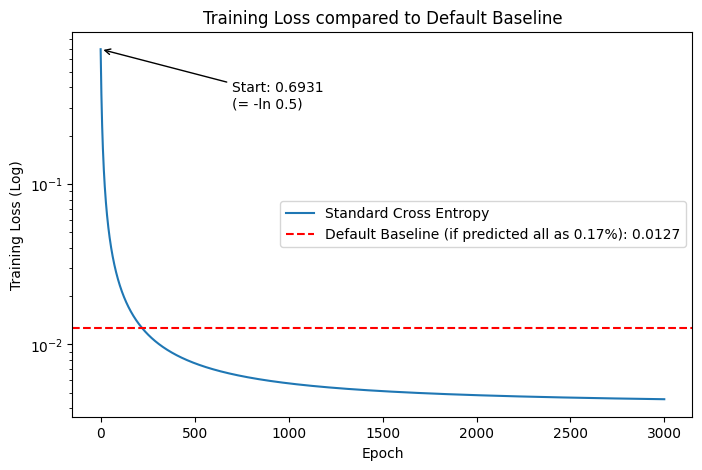

In [147]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history, label="Standard Cross Entropy")
plt.axhline(logLoss, color="red", linestyle="--", label=f"Default Baseline (if predicted all as 0.17%): {logLoss:.4f}")
plt.annotate(f"Start: {history[0]:.4f}\n(= -ln 0.5)", xy=(0, history[0]), xytext=(700, 0.30), arrowprops=dict(arrowstyle='->'))
plt.annotate(f"Final: {history[-1]:.4f}", xy=(10000, history[-1]), xytext=(8800, 0.009), arrowprops=dict(arrowstyle='->'))
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Training Loss (Log)")
plt.title("Training Loss compared to Default Baseline")
plt.legend()
plt.show()

In [148]:
topAlerts = 100
models = [("Standard", validationP, wBaseBCE, bBaseBCE), ("Weighted", validationWeightedP, weightedW, weightedB)]

for name, valProbabilities, weight, bias in models:

  threshold = np.sort(valProbabilities)[::-1][topAlerts - 1]
  testP = probability_prediction(X_testScaled, weight, bias)
  flaggedTestX = testP > threshold

  alerts = flaggedTestX.sum()
  frauds = (y_test.values).sum()

  trueP = (flaggedTestX & (y_test.values == 1)).sum()
  falseP = alerts - trueP
  falseN = frauds - trueP
  trueN = len(y_test.values) - trueP - falseP - falseN

  print(f"{name} Model, Threshold {threshold:.4f}")
  print(f"Alerts raised: {alerts}")
  print(f"Frauds Caught: {trueP} of {y_test.values.sum()}")
  print(f"Precision: {trueP/alerts:.4f}")
  print(f"Recall: {trueP/frauds:.4f}")
  print(f"   True Positives    {trueP:4d}      False Negatives    {falseN:4d}")
  print(f"   False Positives   {falseN:4d}       True Negatives    {trueN:4d}")
  print()




Standard Model, Threshold 0.1249
Alerts raised: 90
Frauds Caught: 76 of 99
Precision: 0.8444
Recall: 0.7677
   True Positives      76      False Negatives      23
   False Positives     23       True Negatives    56849

Weighted Model, Threshold 1.0000
Alerts raised: 93
Frauds Caught: 78 of 99
Precision: 0.8387
Recall: 0.7879
   True Positives      78      False Negatives      21
   False Positives     21       True Negatives    56848



In [175]:
def trainModel(X, y, alpha=None, lr=0.5, epochs=3000):
  w = np.zeros(X.shape[1])
  b = 0

  for epoch in range(epochs):
    p = probability_prediction(X, w, b)
    if alpha is None:
      gradW, gradB = gradient(X, y, p)
    else:
      gradW, gradB = weightedGradient(X, y, p, alpha)

    w -= lr * gradW
    b -= lr * gradB
  return w, b

seeds = []
for seed in range (5):
  Xtr, Xrem, ytr, yrem = train_test_split(X, y, test_size=0.4, stratify=y, random_state=seed)

  Xval, _, yval, _ = train_test_split (Xrem, yrem, test_size=0.5, stratify=yrem, random_state=seed)

  sc = StandardScaler()
  XtrS = sc.fit_transform(Xtr)
  XvS = sc.transform(Xval)
  ytrV, yvV = ytr.values, yval.values

  a = (ytrV == 0).sum() / (ytrV == 1).sum()

  sW, sB = trainModel(XtrS, ytrV, alpha=None)
  wW, wB = trainModel(XtrS, ytrV, alpha = a)

  sP = probability_prediction(XvS, sW, sB)
  wP = probability_prediction(XvS, wW, wB)
  standardSorted = np.argsort(sP)[::-1]
  weightedSorted = np.argsort(wP)[::-1]

  seeds.append(
      {
          "StandardPR-AUC": average_precision_score(yvV, sP),
          "WeightedPR-AUC": average_precision_score(yvV, wP),
          "StandardAt100": yvV[standardSorted[:100]].sum(),
          "WeightedAt100": yvV[weightedSorted[:100]].sum(),
          "StandardBias": sB,
          "WeightedBias": wB
      }
  )

  print(f"Seed {seed}:")
  print(f"                    Standard                        Weighted")
  print(f"PR-AUC:               {seeds[-1]['StandardPR-AUC']:.4f}                          {seeds[-1]['WeightedPR-AUC']:.4f}")
  print(f"Recall at 100:       {seeds[-1]['StandardAt100']:.4f}                         {seeds[-1]['WeightedAt100']:.4f}")
  print(f"Bias:                {seeds[-1]['StandardBias']:.4f}                         {seeds[-1]['WeightedBias']:.4f}")
  print()

results = pd.DataFrame(seeds)
print(f"Mean +/- Standard Deviation over 5 splits (standard/weighted):")
for col in results.columns:
  print(f"{col:14s}: {results[col].mean():9.4f} +/- {results[col].std():.4f}")



Seed 0:
                    Standard                        Weighted
PR-AUC:               0.7630                          0.7338
Recall at 100:       80.0000                         80.0000
Bias:                -7.0820                         -3.6487

Seed 1:
                    Standard                        Weighted
PR-AUC:               0.7521                          0.7198
Recall at 100:       77.0000                         75.0000
Bias:                -7.0688                         -3.2860

Seed 2:
                    Standard                        Weighted
PR-AUC:               0.7507                          0.7169
Recall at 100:       78.0000                         79.0000
Bias:                -7.0698                         -3.9715

Seed 3:
                    Standard                        Weighted
PR-AUC:               0.8156                          0.7819
Recall at 100:       80.0000                         80.0000
Bias:                -7.0634                      